# Análisis financiero

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.metrics import confusion_matrix



In [2]:
df= pd.read_csv('GermanData_Credit.csv', header= None)
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


Tenemos un archivo codificado que puede encontrase en https://www.kaggle.com/datasets/ewelinak/german-credit-dataset-orginal-from-uci o la fuente con los archivos para la codificación: Hofmann, H. (1994). Statlog (German Credit Data) [Dataset]. UCI Machine Learning Repository  https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data





Donde podemos encontrar el siguiente diccionario


Attribute 1:  (qualitative)      
   
    Status of existing checking account
            
			A11 :      ... <    0 DM
	        A12 : 0 <= ... <  200 DM
	        A13 :      ... >= 200 DM / salary assignments for at least 1 year
            A14 : no checking account

Attribute 2:  (numerical)
	
	Duration in month

Attribute 3:  (qualitative)
	
	Credit history
	        A30 : no credits taken/ all credits paid back duly
            A31 : all credits at this bank paid back duly
	        A32 : existing credits paid back duly till now
            A33 : delay in paying off in the past
	        A34 : critical account/  other credits existing (not at this bank)

Attribute 4:  (qualitative)
	
	Purpose
	      A40 : car (new)
	      A41 : car (used)
	      A42 : furniture/equipment
	      A43 : radio/television
	      A44 : domestic appliances
	      A45 : repairs
	      A46 : education
	      A47 : (vacation - does not exist?)
	      A48 : retraining
	      A49 : business
	      A410 : others

Attribute 5:  (numerical)
	
	Credit amount

Attibute 6:  (qualitative)
	
	Savings account/bonds
	      A61 :          ... <  100 DM
	      A62 :   100 <= ... <  500 DM
	      A63 :   500 <= ... < 1000 DM
	      A64 :          .. >= 1000 DM
          A65 :   unknown/ no savings account

Attribute 7:  (qualitative)
	      
	Present employment since
	      A71 : unemployed
	      A72 :       ... < 1 year
	      A73 : 1  <= ... < 4 years  
	      A74 : 4  <= ... < 7 years
	      A75 :       .. >= 7 years

Attribute 8:  (numerical)
	      
	Installment rate in percentage of disposable income

Attribute 9:  (qualitative)
	      
	Personal status and sex
	      A91 : male   : divorced/separated
	      A92 : female : divorced/separated/married
          A93 : male   : single
	      A94 : male   : married/widowed
	      A95 : female : single

Attribute 10: (qualitative)
	
	Other debtors / guarantors
	      A101 : none
	      A102 : co-applicant
	      A103 : guarantor

Attribute 11: (numerical)
	Present residence since

Attribute 12: (qualitative)
	
	Property
	      A121 : real estate
	      A122 : if not A121 : building society savings agreement/ life insurance
          A123 : if not A121/A122 : car or other, not in attribute 6
	      A124 : unknown / no property

Attribute 13: (numerical)
	
	Age in years

Attribute 14: (qualitative)
	
	Other installment plans 
	      A141 : bank
	      A142 : stores
	      A143 : none

Attribute 15: (qualitative)
	
	Housing
	      A151 : rent
	      A152 : own
	      A153 : for free

Attribute 16: (numerical)
    
	Number of existing credits at this bank

Attribute 17: (qualitative)
	
	Job
	      A171 : unemployed/ unskilled  - non-resident
	      A172 : unskilled - resident
	      A173 : skilled employee / official
	      A174 : management/ self-employed/highly qualified employee/ officer

Attribute 18: (numerical)
	      
	Number of people being liable to provide maintenance for

Attribute 19: (qualitative)
	
	Telephone
	      A191 : none
	      A192 : yes, registered under the customers name

Attribute 20: (qualitative)
	
	foreign worker
	      A201 : yes
	      A202 : no






In [3]:
def decode_raw_uci_statlog(df:pd.DataFrame ) -> pd.DataFrame:
    
    
    col_names = [
        "checking_acc_status", "duration", "cred_hist", "purpose", "loan_amt",
        "saving_acc_bonds", "present_employment_since", "installment_rate",
        "personal_stat_gender", "other_debtors_guarantors", "present_residence_since",
        "property", "age", "other_installment_plans", "housing", "num_curr_loans",
        "job", "num_people_provide_maint", "telephone", "is_foreign_worker", "class",
    ]
    df.columns=col_names
    DECODE_MAPS = {
        "checking_acc_status": {
            "A11": "below_0", "A12": "below_200", "A13": "above_200", "A14": "no_checking_acc",
        },
        "cred_hist": {
            "A30": "no_loan_or_paid_duly_other", "A31": "paid_duly_this_bank",
            "A32": "curr_loans_paid_duly", "A33": "delay_in_past",
            "A34": "risky_acc_or_curr_loan_other",
        },
        "purpose": {
            "A40": "car_new", "A41": "car_used", "A42": "furniture_equipment",
            "A43": "radio_tv", "A44": "domestic_appliance", "A45": "repairs",
            "A46": "education", "A47": "vacation", "A48": "retraining",
            "A49": "business", "A410": "others",
        },
        "saving_acc_bonds": {
            "A61": "below_100", "A62": "below_500", "A63": "below_1000",
            "A64": "above_1000", "A65": "unknown_no_saving_acc",
        },
        "present_employment_since": {
            "A71": "unemployed", "A72": "below_1y", "A73": "below_4y",
            "A74": "below_7y", "A75": "above_7y",
        },
        "personal_stat_gender": {
            "A91": "male_divorced_separated", "A92": "female_divorced_separated_married",
            "A93": "male_single", "A94": "male_married_widowed", "A95": "female_single",
        },
        "other_debtors_guarantors": {"A101": "none", "A102": "co-applicant", "A103": "guarantor"},
        "property": {
            "A121": "real_estate", "A122": "life_insurance_or_agreements",
            "A123": "car_or_other", "A124": "unknown_or_no_property",
        },
        "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
        "housing": {"A151": "rent", "A152": "own", "A153": "free"},
        "job": {
            "A171": "unemployed_non_resident", "A172": "unskilled_resident",
            "A173": "skilled_official", "A174": "management_or_self_emp",
        },
        "telephone": {"A191": "none", "A192": "yes"},
        "is_foreign_worker": {"A201": "yes", "A202": "no"},
    }

    for col, mapping in DECODE_MAPS.items():
        df[col] = df[col].map(mapping).fillna(df[col])  # deja el código crudo si no matchea, en vez de NaN

    # 'class' ya viene numérica (1=good, 2=bad) — se deja tal cual, _process_credit_dataframe
    # ya sabe interpretar ese formato vía TARGET_VALUE_MAP.
    return df

In [4]:
decode_raw_uci_statlog(df)

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,class
0,below_0,6,risky_acc_or_curr_loan_other,radio_tv,1169,unknown_no_saving_acc,above_7y,4,male_single,none,...,real_estate,67,none,own,2,skilled_official,1,yes,yes,1
1,below_200,48,curr_loans_paid_duly,radio_tv,5951,below_100,below_4y,2,female_divorced_separated_married,none,...,real_estate,22,none,own,1,skilled_official,1,none,yes,2
2,no_checking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,1
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male_single,guarantor,...,life_insurance_or_agreements,45,none,free,1,skilled_official,2,none,yes,1
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male_single,none,...,unknown_or_no_property,53,none,free,2,skilled_official,2,none,yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_checking_acc,12,curr_loans_paid_duly,furniture_equipment,1736,below_100,below_7y,3,female_divorced_separated_married,none,...,real_estate,31,none,own,1,unskilled_resident,1,none,yes,1
996,below_0,30,curr_loans_paid_duly,car_used,3857,below_100,below_4y,4,male_divorced_separated,none,...,life_insurance_or_agreements,40,none,own,1,management_or_self_emp,1,yes,yes,1
997,no_checking_acc,12,curr_loans_paid_duly,radio_tv,804,below_100,above_7y,4,male_single,none,...,car_or_other,38,none,own,1,skilled_official,1,none,yes,1
998,below_0,45,curr_loans_paid_duly,radio_tv,1845,below_100,below_4y,4,male_single,none,...,unknown_or_no_property,23,none,free,1,skilled_official,1,yes,yes,2


In [5]:
print('El dataset tiene las siguientes caracteristicas')
print('La forma:', df.shape)
df.info()
df.describe()

El dataset tiene las siguientes caracteristicas
La forma: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_acc_status       1000 non-null   object
 1   duration                  1000 non-null   int64 
 2   cred_hist                 1000 non-null   object
 3   purpose                   1000 non-null   object
 4   loan_amt                  1000 non-null   int64 
 5   saving_acc_bonds          1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_stat_gender      1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_inst

,duration,loan_amt,installment_rate,present_residence_since,age,num_curr_loans,num_people_provide_maint,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Aquí verificamos que el dataframe contiene la información que mencionan en la fuente, donde no tenemos espacios nulos, tenemos 1000 entradas y 21 columnas 

Agreguemos una columna para mejorar la interpretación de las clases

In [6]:
df['credit_risk']= df['class'].map({1:'buenos',2:'malos'})

## EDA

Realizaremos el análisis exploratorio revisando la distribución y categorías asociadas a alto riesgo crediticio

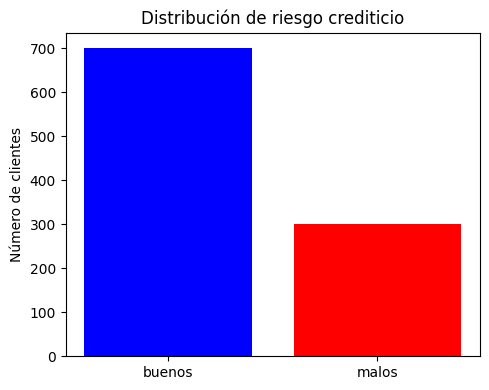

In [7]:
risk_counts= df['credit_risk'].value_counts()
bad_rate= (df['credit_risk'] == 'malos').mean()

plt.figure(figsize = (5,4))
colors = ['blue' if x=='buenos' else 'red' for x in risk_counts.index]
plt.bar(risk_counts.index, risk_counts.values, color=colors)
plt.ylabel('Número de clientes')
plt.title('Distribución de riesgo crediticio')
plt.tight_layout()
plt.show()

In [8]:
print(f"Tasa de malos: {bad_rate:.1%}")

df.columns

Tasa de malos: 30.0%


Index(['checking_acc_status', 'duration', 'cred_hist', 'purpose', 'loan_amt',
       'saving_acc_bonds', 'present_employment_since', 'installment_rate',
       'personal_stat_gender', 'other_debtors_guarantors',
       'present_residence_since', 'property', 'age', 'other_installment_plans',
       'housing', 'num_curr_loans', 'job', 'num_people_provide_maint',
       'telephone', 'is_foreign_worker', 'class', 'credit_risk'],
      dtype='object')

Con esto nos damos cuenta que aun que tenemos una base de datos desequilibrada, el desbalance es moderado (70/30 aprox), sin embargo habra que tenerlo en cuenta para el análisis

#### Distribucion de variables numericas

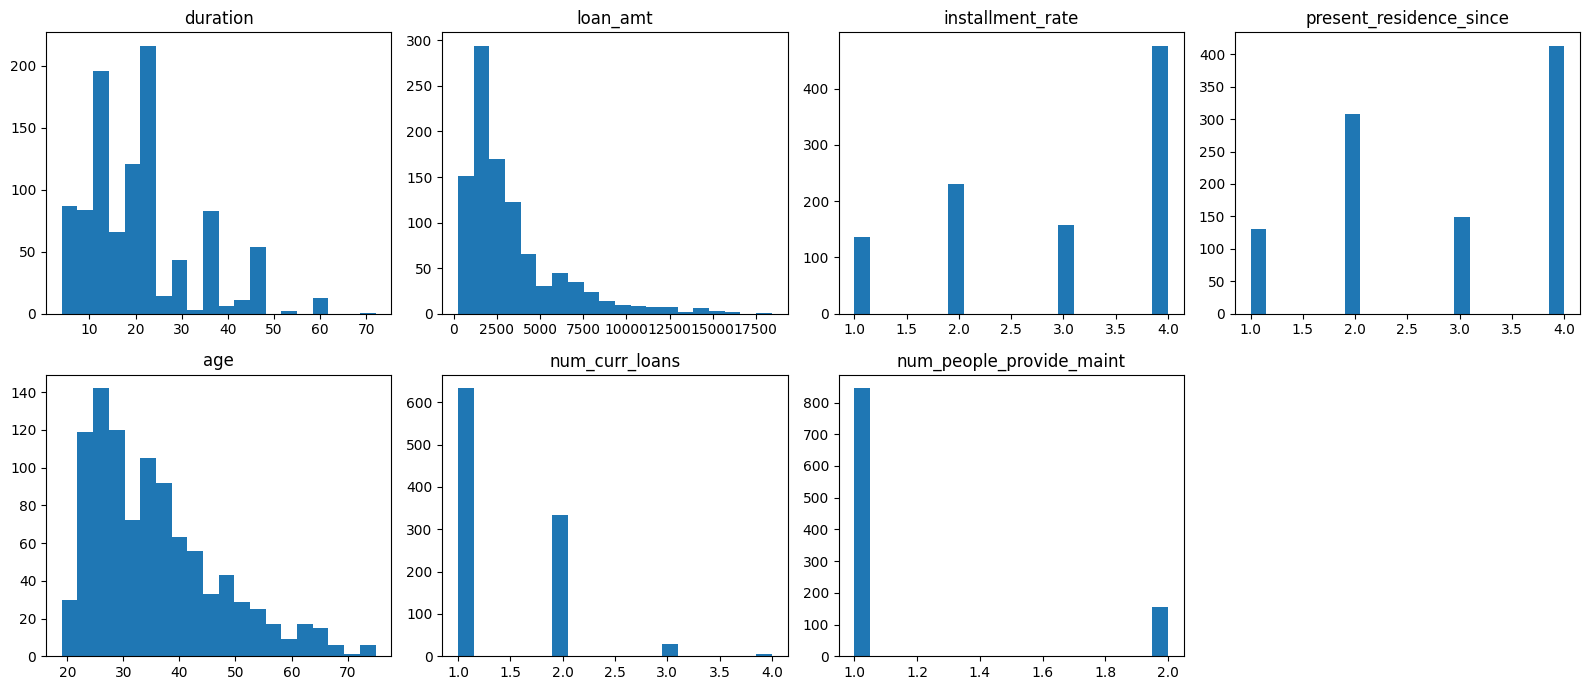

In [9]:
numeric_cols= ['duration', 'loan_amt', 'installment_rate',
       'present_residence_since', 'age', 'num_curr_loans', 'num_people_provide_maint']


fig, axes = plt.subplots(2,4, figsize=(16,7))
axes= axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Aquí podemos observar es que la variable 'loan_amt' tiene una asimetria mayor a las otras variables, también observamos los rangos de edad, también observamos las diferencias en las escalas

## 

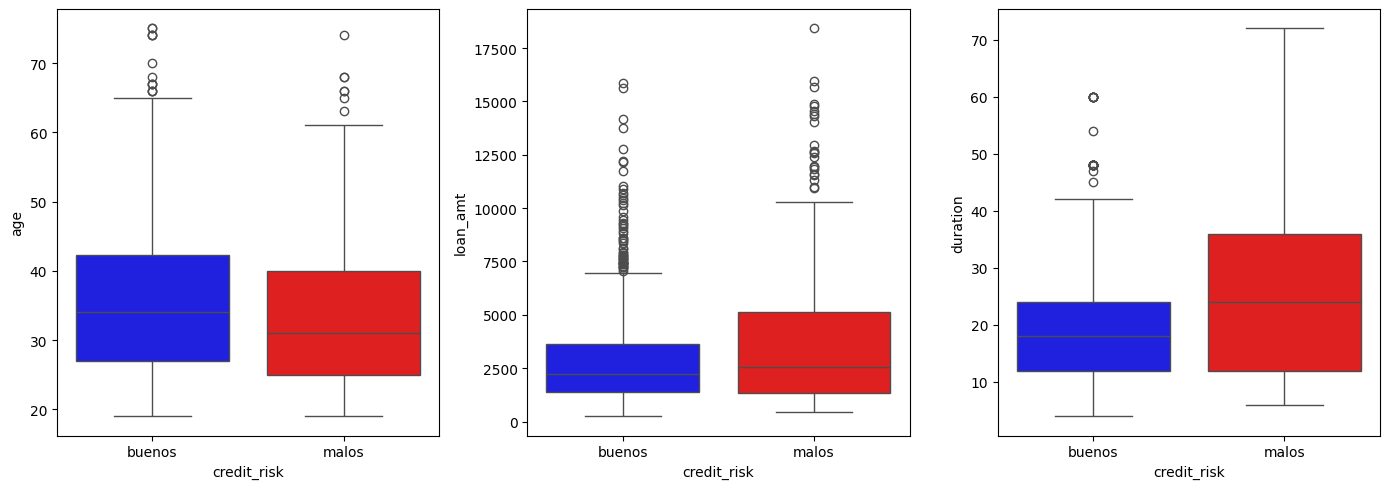

In [10]:
fig, axes = plt.subplots(1,3, figsize=(14,5))
for i, col in zip(axes, ['age', 'loan_amt', 'duration']):
    sns.boxplot(data=df, x='credit_risk', y=col, hue='credit_risk', ax=i, palette={'buenos': 'blue', 'malos':'red'}, legend=False)
plt.tight_layout()
plt.show()

Aquí podemos observar que la mayor diferencia de reisgo de credito se encuentra en la duración de crédito, donde observamos que a mayor duración mayor riesgo. 

Ahora para visualizar la variables categoricas respecto a la tasa de malos

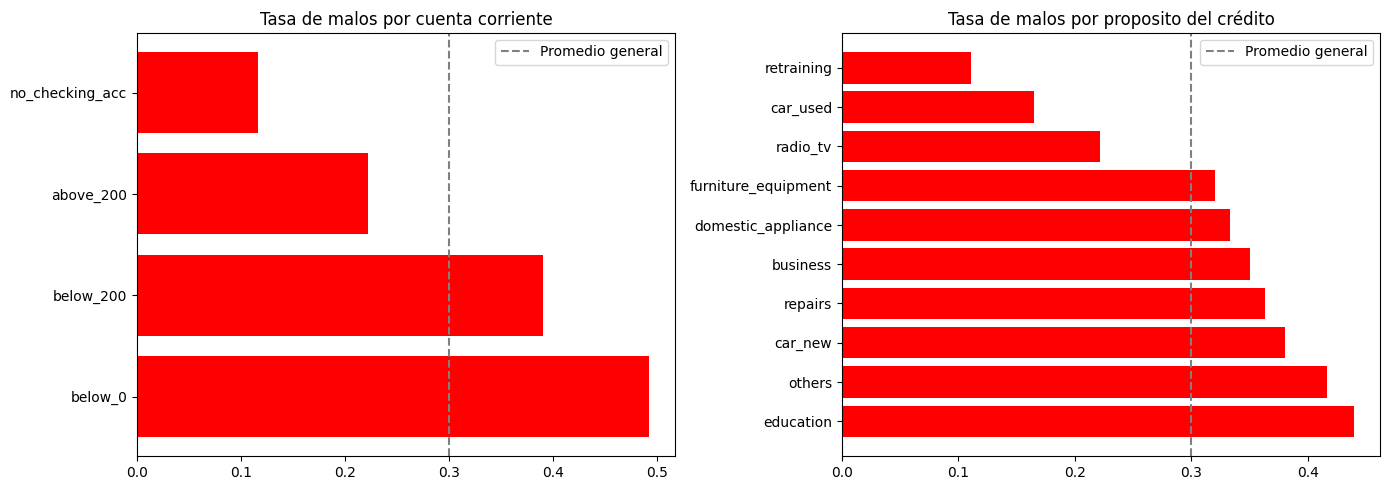

In [11]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
checking_risk = df.groupby('checking_acc_status')['class'].apply(lambda x: (x==2).mean()).sort_values(ascending = False)
axes[0].barh(checking_risk.index, checking_risk.values, color='red')
axes[0].axvline(bad_rate, color='gray', linestyle = '--', label='Promedio general')
axes[0].set_title('Tasa de malos por cuenta corriente')
axes[0].legend()

purpose_risk = df.groupby('purpose')['class'].apply(lambda x: (x==2).mean()).sort_values(ascending = False)
axes[1].barh(purpose_risk.index, purpose_risk.values, color='red')
axes[1].axvline(bad_rate, color='gray', linestyle = '--', label='Promedio general')
axes[1].set_title('Tasa de malos por proposito del crédito')
axes[1].legend()

plt.tight_layout()
plt.show()

Aquí podemos observar que para el caso de cuenta corriente la mayor proporción de tasa de malos se encuentra en el conjunto 'below_0', sin embargo se observa que el conjunto 'no_checking_account' tiene la menor proporción, lo que nos hace pensar que este conjunto necesita revisarse más ampliamente.

### Segmentación de clientes y riesgo crediticio

Para esta sección nos haremos varias preguntas:

¿Cómo luce un cliente típico?
¿Existen grupos naturales de clientes?
¿Qué distingue a cada grupo?
¿Podemos predecir el riesgo?

In [12]:
## Calculemos la correlación entre las variables numéricas y el riesgo crediticio

correlation = df[numeric_cols + ['class']].corr() 
correlation.round(3)


,duration,loan_amt,installment_rate,present_residence_since,age,num_curr_loans,num_people_provide_maint,class
duration,1.000,0.625,0.075,0.034,-0.036,-0.011,-0.024,0.215
loan_amt,0.625,1.000,-0.271,0.029,0.033,0.021,0.017,0.155
installment_rate,0.075,-0.271,1.000,0.049,0.058,0.022,-0.071,0.072
present_residence_since,0.034,0.029,0.049,1.000,0.266,0.090,0.043,0.003
age,-0.036,0.033,0.058,0.266,1.000,0.149,0.118,-0.091
num_curr_loans,-0.011,0.021,0.022,0.090,0.149,1.000,0.110,-0.046
num_people_provide_maint,-0.024,0.017,-0.071,0.043,0.118,0.110,1.000,-0.003
class,0.215,0.155,0.072,0.003,-0.091,-0.046,-0.003,1.000


In [13]:
 df[numeric_cols + ['class']].corr()['class'].drop('class').sort_values(key=abs, ascending=False)    

duration                    0.214927
loan_amt                    0.154739
age                        -0.091127
installment_rate            0.072404
num_curr_loans             -0.045732
num_people_provide_maint   -0.003015
present_residence_since     0.002967
Name: class, dtype: float64

Con esto confirmamos que la duración del crédito es una de las variables númericas más importantes, sin embargo, con esto no podemos capturar la influencia de las variables categoricas.

### ¿Existen grupos naturales?

#### Preprocesamiento de datos

In [14]:
## Eliminamos las columnas 'class' y 'credit_risk' columnas en un nuevo dataset que se usara para los modelos y 
# agregamos la columna 'default para convertirla en binaria (0,1) 
model_df = df.drop(columns=['class', 'credit_risk']).copy() 
model_df['default'] = df['class'].map({1: 0, 2: 1})

## nuevo dataset para los modelos con la columna target = 'default' y feature = resto de columnas.



In [15]:
feature_cols_raw = [c for c in model_df.columns if c != 'default']
numeric_feature_cols = [c for c in feature_cols_raw if pd.api.types.is_numeric_dtype(model_df[c])] ##Lista de columnas númericas
categorical_feature_cols = [c for c in feature_cols_raw if c not in numeric_feature_cols] #Lista de columnas categóricas
print(f'Numéricas ({len(numeric_feature_cols)}):', numeric_feature_cols)
print(f'Categóricas ({len(categorical_feature_cols)}):', categorical_feature_cols)

encoded_df = pd.get_dummies(model_df, columns=categorical_feature_cols, drop_first=True) # Se generan dummies 
scaler = StandardScaler()
encoded_df[numeric_feature_cols] = scaler.fit_transform(encoded_df[numeric_feature_cols])



feature_cols = [c for c in encoded_df.columns if c != 'default']
X = encoded_df[feature_cols].values
y = encoded_df['default']
print(f'\nDimensiones finales de X: {X.shape}')

Numéricas (7): ['duration', 'loan_amt', 'installment_rate', 'present_residence_since', 'age', 'num_curr_loans', 'num_people_provide_maint']
Categóricas (13): ['checking_acc_status', 'cred_hist', 'purpose', 'saving_acc_bonds', 'present_employment_since', 'personal_stat_gender', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'is_foreign_worker']

Dimensiones finales de X: (1000, 48)


   k    inertia  silhouette
0  2  10908.920       0.139
1  3  10036.632       0.105
2  4   9276.559       0.108
3  5   8816.789       0.092
4  6   8479.999       0.091
5  7   8231.220       0.082
6  8   8039.677       0.077
7  9   7846.117       0.082


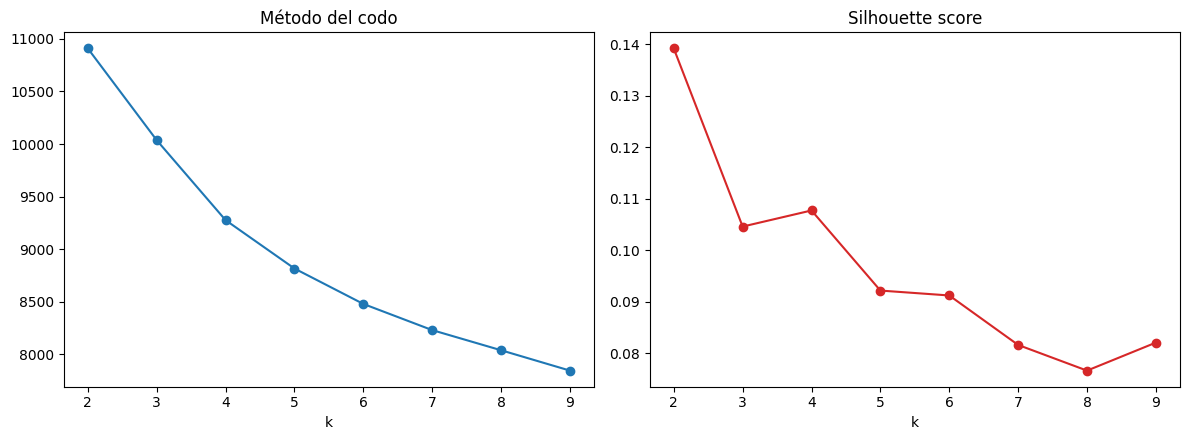

In [16]:
## Obtendremos el valor óptimo de k para KMeans

k_range = range(2, 10)
results = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})
k_results = pd.DataFrame(results)
print(k_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_results['k'], k_results['inertia'], marker='o')
axes[0].set_xlabel('k'); axes[0].set_title('Método del codo')
axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='#d62728')
axes[1].set_xlabel('k'); axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

Como podemos ver en los resultados, con el método del codo tenemos que el número k 2 y 3 con mayores cambios, mientras que en Silhouette k = 2 es el que tiene un valor más alto en comparación a los demás, por lo que será el valor que usaremos, sin embargo, vale la pena mencionar que con un valor de 0.13 la segmentación se 'solapa', por lo que no percibimos dos grupos fuertemente definidos pero es un valor suficiente para considerarlos como dos conjuntos.

In [17]:
## Perfil de los clusters

kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X)

profile_df = model_df.copy()
profile_df['cluster'] = cluster_labels
profile = profile_df.groupby('cluster')[numeric_feature_cols].mean().round(2)
profile['n_customers'] = profile_df.groupby('cluster').size()
print(profile)

         duration  loan_amt  installment_rate  present_residence_since    age  \
cluster                                                                         
0           36.15   7348.86              2.59                     2.92  36.26   
1           16.42   2073.83              3.09                     2.82  35.34   

         num_curr_loans  num_people_provide_maint  n_customers  
cluster                                                         
0                  1.50                      1.18          227  
1                  1.38                      1.15          773  


/var/folders/t1/0jvm0wbj3td5t2jsp_mb8gj00000gn/T/ipykernel_54546/3035657894.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


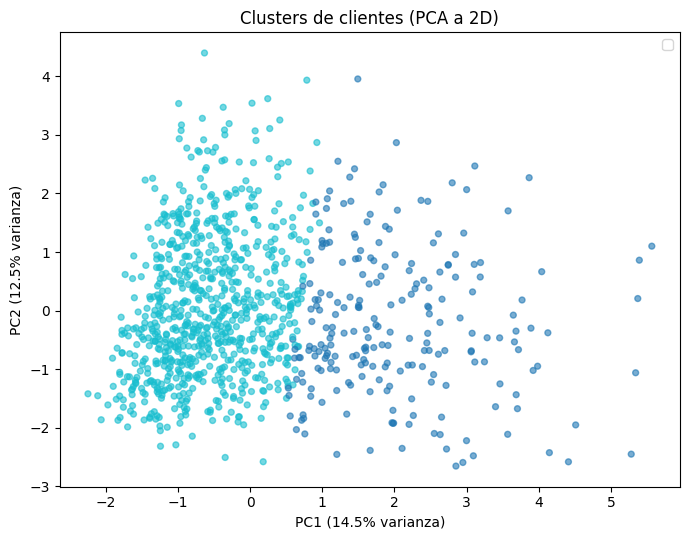

In [18]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(7, 5.5))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=18)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Clusters de clientes (PCA a 2D)')
plt.legend()
plt.tight_layout()
plt.show()

En esta figura notamos como los dos conjuntos se solapan en los valores entre 0 y 2, por lo que confirmamos las conclusiones obtenidas anteriormente

Ahora bien, para una mejor interpretación de la segmentación tenermos que realizar un perfil más detallado de los clusters, por lo que realizaremos un perfil con las variables categoricas también

In [21]:
# Mostramos nuevamente el perfil númerico
print("=== Perfil numérico ===")
print(profile_df.groupby('cluster')[numeric_feature_cols].mean().round(1))
print()
print("n_clientes por cluster:", profile_df.groupby('cluster').size().to_dict())
print()

# Perfil categórico: moda 
print("=== Categoría más común por cluster ===")
for col in categorical_feature_cols:
    modes = profile_df.groupby('cluster')[col].agg(lambda x: x.value_counts().index[0])
    pcts = profile_df.groupby('cluster')[col].agg(lambda x: x.value_counts(normalize=True).iloc[0])
    print(f"{col}:")
    for cl in sorted(profile_df['cluster'].unique()):
        print(f"  Cluster {cl}: {modes[cl]} ({pcts[cl]:.0%})")


=== Perfil numérico ===
         duration  loan_amt  installment_rate  present_residence_since   age  \
cluster                                                                        
0            36.2    7348.9               2.6                      2.9  36.3   
1            16.4    2073.8               3.1                      2.8  35.3   

         num_curr_loans  num_people_provide_maint  
cluster                                            
0                   1.5                       1.2  
1                   1.4                       1.1  

n_clientes por cluster: {0: 227, 1: 773}

=== Categoría más común por cluster ===
checking_acc_status:
  Cluster 0: below_200 (35%)
  Cluster 1: no_checking_acc (41%)
cred_hist:
  Cluster 0: curr_loans_paid_duly (43%)
  Cluster 1: curr_loans_paid_duly (56%)
purpose:
  Cluster 0: car_used (24%)
  Cluster 1: radio_tv (31%)
saving_acc_bonds:
  Cluster 0: below_100 (59%)
  Cluster 1: below_100 (61%)
present_employment_since:
  Cluster 0: below_4y

         default_rate  n_customers
cluster                           
0               0.436          227
1               0.260          773


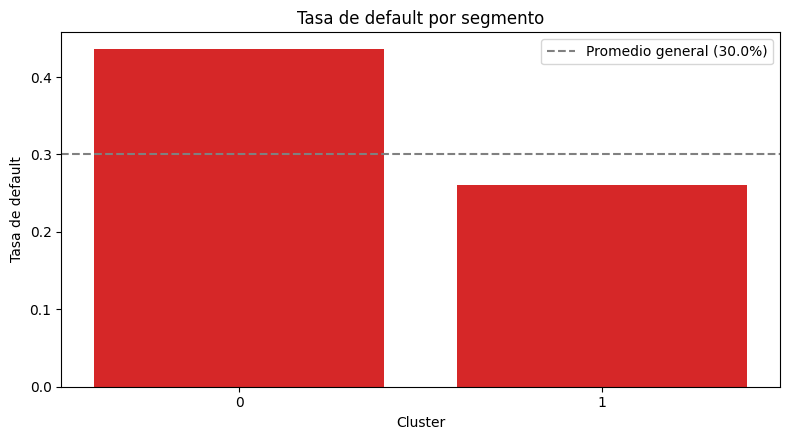

In [22]:
default_by_cluster = profile_df.groupby('cluster')['default'].agg(['mean', 'size']).round(3)
default_by_cluster.columns = ['default_rate', 'n_customers']
print(default_by_cluster.sort_values('default_rate', ascending=False))

plt.figure(figsize=(8, 4.5))
sorted_df = default_by_cluster.sort_values('default_rate', ascending=False)
plt.bar(sorted_df.index.astype(str), sorted_df['default_rate'], color='#d62728')
plt.axhline(y.mean(), color='gray', linestyle='--', label=f'Promedio general ({y.mean():.1%})')
plt.xlabel('Cluster'); plt.ylabel('Tasa de default'); plt.legend()
plt.title('Tasa de default por segmento')
plt.tight_layout()
plt.show()

Con esta información podemos darle una interpretación a la segmentación, donde:

Cluster 0: Con 227 clientes y una taza de malos del 43%, se asocia a clientes con una dursación promedio del crédito de 36 meses, un monto promedio de $7,349, un estatus de cuenta 'below 200' y el proposito del crédito más común un auto usado.

Cluster 1: Con 773 clientes y una taza de malos del 26%, se asocia a clientes con una dursación promedio del crédito de 16 meses, un monto promedio de $2,074, un estatus de cuenta 'no_checking_acc' y el proposito del crédito más común radio/tv.

Mientras que las variables restantes no tienen diferenciadores tan relevantes, estos datos nos llevan a la conclusión de que créditos más largos y de mayor monto tienen una tasa de malos superior a los créditos mas cortos y de menor monto.

Estos nos da indicios de que el riesgo esta más ligado al producto que al perfil del cliente.

## Scoring de riesgo

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    encoded_df[feature_cols], y, test_size=0.25, stratify=y, random_state=42
)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_proba)
    print(f'--- {name} ---')
    print(f'AUC-ROC: {auc:.3f}')

--- Logistic Regression ---
AUC-ROC: 0.807
--- Random Forest ---
AUC-ROC: 0.795


Podemos ver que ambos modelos tienen un desempeño similar, ahora revisando las curvas ROC

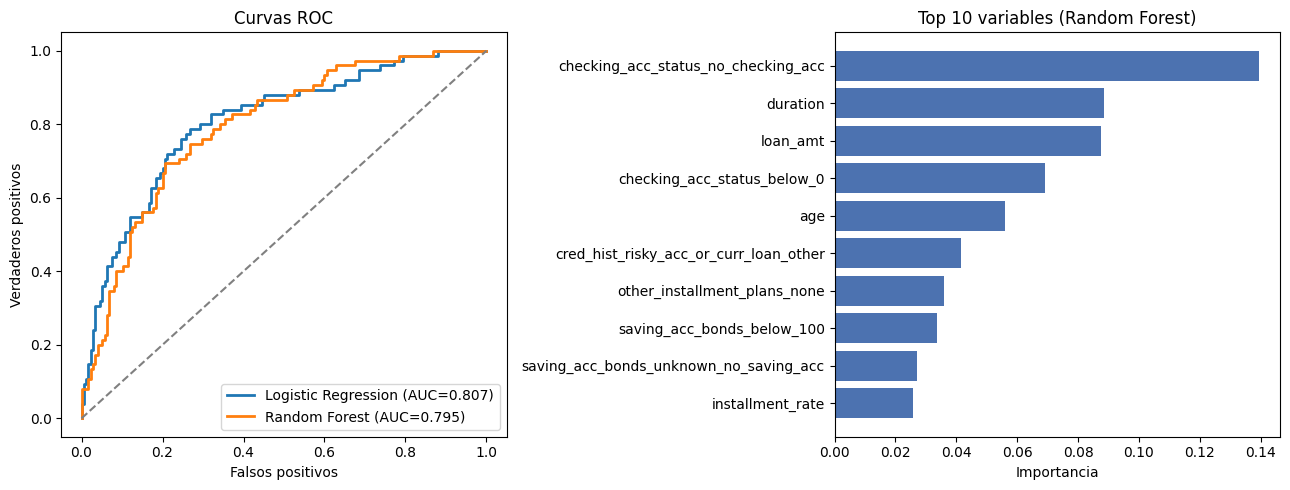

                                   feature  importance
9      checking_acc_status_no_checking_acc    0.139379
0                                 duration    0.088666
1                                 loan_amt    0.087540
7              checking_acc_status_below_0    0.068978
4                                      age    0.055839
13  cred_hist_risky_acc_or_curr_loan_other    0.041687
39            other_installment_plans_none    0.035932
23              saving_acc_bonds_below_100    0.033785
26  saving_acc_bonds_unknown_no_saving_acc    0.027030
2                         installment_rate    0.025774


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[0].plot([0,1],[0,1], linestyle='--', color='gray')
axes[0].set_xlabel('Falsos positivos'); axes[0].set_ylabel('Verdaderos positivos')
axes[0].set_title('Curvas ROC'); axes[0].legend()

importance_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)
axes[1].barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#4c72b0')
axes[1].set_xlabel('Importancia'); axes[1].set_title('Top 10 variables (Random Forest)')

plt.tight_layout()
plt.show()
print(importance_df)

Nuevamente vemos un desempeño muy similar que nos lleva a pensar que la relacion entre las variables es mayormente lineal.

Ahora revisemos la matriz de confusion



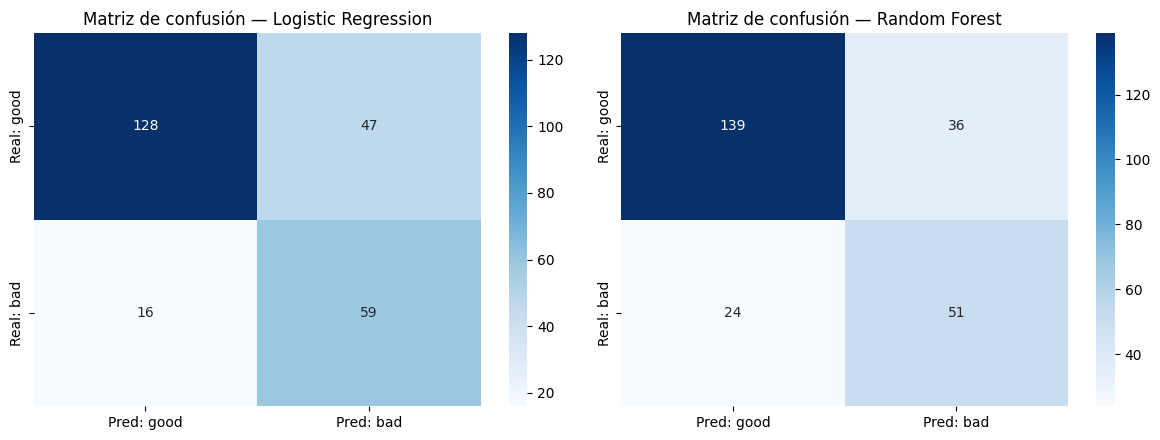

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, model) in zip(axes, [('Logistic Regression', log_reg), ('Random Forest', rf)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: good', 'Pred: bad'],
                yticklabels=['Real: good', 'Real: bad'])
    ax.set_title(f'Matriz de confusión — {name}')

plt.tight_layout()
plt.show()

In [35]:
for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
	y_proba = model.predict_proba(X_test)[:, 1]
	y_pred = model.predict(X_test)
	print(f'--- {name} ---')
	print(classification_report(y_test, y_pred, target_names=['buenos','malos']))

--- Logistic Regression ---
              precision    recall  f1-score   support

      buenos       0.89      0.73      0.80       175
       malos       0.56      0.79      0.65        75

    accuracy                           0.75       250
   macro avg       0.72      0.76      0.73       250
weighted avg       0.79      0.75      0.76       250

--- Random Forest ---
              precision    recall  f1-score   support

      buenos       0.85      0.79      0.82       175
       malos       0.59      0.68      0.63        75

    accuracy                           0.76       250
   macro avg       0.72      0.74      0.73       250
weighted avg       0.77      0.76      0.76       250



Aquí podemos ver que para el caso del modelo de la regresión logística tenemos que:

	- Identifico el 79% del tiempo a los clientes realmente malos. Solo 16 de 75 no fueron identificados.
	- Tenemos 44% que se identificaron como malos y realmente eran buenos clientes.

Para random forest tenemos que:

	- Identifico 68% a clientes realmente malos, es decir 24 clientes malos no fueron identidicados y pasaron como buenos.
	- Identifico 41% como malos clientes cuando realimente eran buenos.

	

#### Conclusiones

Encontramos dos clusters de clientes que aún que se traslapan entre si, pero con una brecha de riesgo de 17.6, por lo que es posible identificarlos, estos grupos tienen como razgo diferenciador más importante al el tipo de producto.

Respecto a los modelos predictivos tenemos que rregresión logística tiene el mejor desempeño con un AUC = 0.807.

También es importante recalcar que para el tipo de negocio, regresión logística es preferible ya que identifico correctamente con más presición a los clientes malos que random forest, esto es mejor, ya que es más costoso clasificar erroneamente por lo que el modelo de regresión logística es el predilecto para este caso.

